R Heatmap

/tmp/ipykernel_2734005/1039745351.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('Reds', 14)


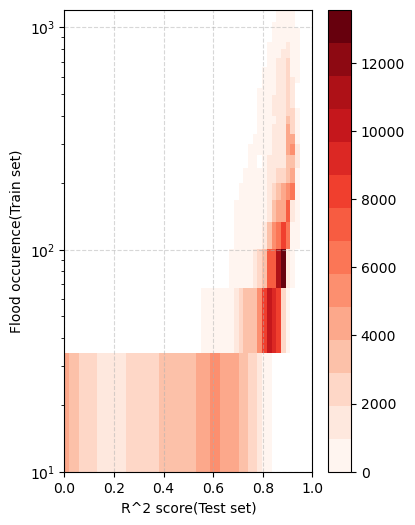

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.colors as mplcolors

#select particular representative gauge
reg = 'CT'
list_size = ['225', '529', '892', '1658', '3454', '7071'] 
columnname = str(38)
mask_size = '892'
train_size = list_size[3]

fig, ax = plt.subplots(1, 1, figsize=(4, 6))
df = pd.read_csv(f'/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/model/{reg}/multifoldMC/PTHA/_Grid_scores_{train_size}.txt', sep=",")
df = df[df['r2'] > 0]
cmap = plt.cm.get_cmap('Reds', 14)
sns.histplot(data=df, x='r2', y='count_train', bins=50, pthresh=.01, cmap=cmap, cbar=True, ax=ax)
# plt.yticks([0,30,100,200,400,800,1200])
plt.ylabel('Flood occurence(Train set)')
plt.xlabel('R^2 score(Test set)')
ax.grid(linestyle='dashed', alpha=0.5)
#y axis log scale
plt.yscale('log')
plt.xlim(0, 1)
plt.ylim(10, 1200)
plt.show()

#save figure
fig.savefig(f'./heatmap_grid_scores_{train_size}_r2.png', dpi=300, bbox_inches='tight')


G Heatmap

/tmp/ipykernel_910756/3536725638.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('Reds', 14)


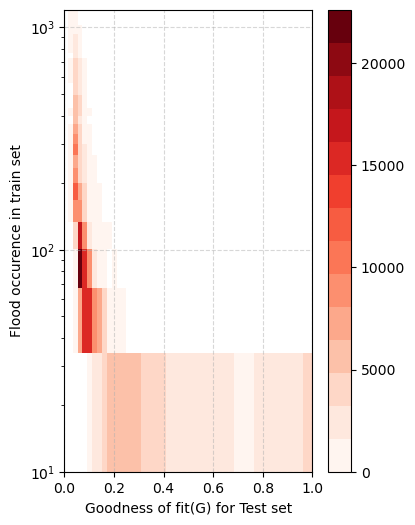

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.colors as mplcolors


#select particular representative gauge
reg = 'CT'
list_size = ['225', '529', '892', '1658', '3454', '7071'] 
columnname = str(38)
mask_size = '892'
train_size = list_size[3]


fig, ax = plt.subplots(1, 1, figsize=(4, 6))
df = pd.read_csv(f'/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/model/{reg}/multifoldMC/PTHA/_Grid_scores_{train_size}.txt', sep=",")
df = df[df['Gfit'] < 1]
cmap = plt.cm.get_cmap('Reds', 14)
sns.histplot(data=df, x='Gfit', y='count_train', bins=50, pthresh=.01, cmap=cmap, ax=ax,alpha=1, cbar=True)
# plt.yticks([0,30,100,200,400,800,1200])
plt.ylabel('Flood occurence in train set')
plt.xlabel('Goodness of fit(G) for Test set')
ax.grid(linestyle='dashed', alpha=0.5)
#y axis log scale
plt.yscale('log')
plt.xlim(0, 1)
plt.ylim(10, 1200)
plt.show()

#save figure
fig.savefig(f'./heatmap_Grid_scores_{train_size}_g.png', dpi=300, bbox_inches='tight')


Prob Weighted

/tmp/ipykernel_2240500/2667745272.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('Reds', 14)


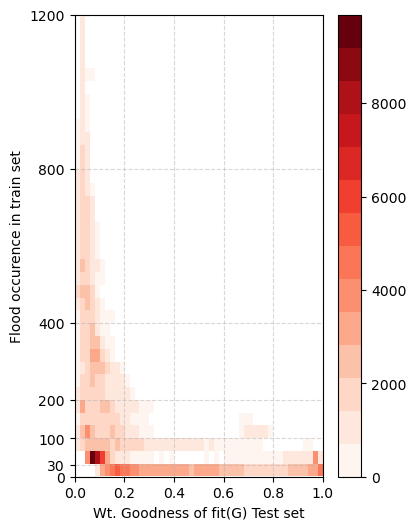

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.colors as mplcolors

#select particular representative gauge
reg = 'CT'
list_size = ['225', '529', '892', '1658', '3454', '7071'] 
columnname = str(38)
mask_size = '892'
train_size = list_size[3]


fig, ax = plt.subplots(1, 1, figsize=(4, 6))
df = pd.read_csv(f'/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/model/{reg}/multifoldMC/PTHA/_Grid_scores_{train_size}_PSHalf.txt', sep=",")
df = df[df['Gfit_test_imp'] < 1]
cmap = plt.cm.get_cmap('Reds', 14)
sns.histplot(data=df, x='Gfit_test_imp', y='count_train', bins=50, pthresh=.1, cmap=cmap, ax=ax,alpha=1, cbar=True)
plt.yticks([0,30,100,200,400,800,1200])
plt.ylabel('Flood occurence in train set')
plt.xlabel('Wt. Goodness of fit(G) Test set')
ax.grid(linestyle='dashed', alpha=0.5)
plt.xlim(0, 1)
plt.ylim(0, 1200)
plt.show()

#save figure
fig.savefig(f'./heatmap_Grid_scores_{train_size}_wt.png', dpi=300, bbox_inches='tight')


Grid Score For Performance

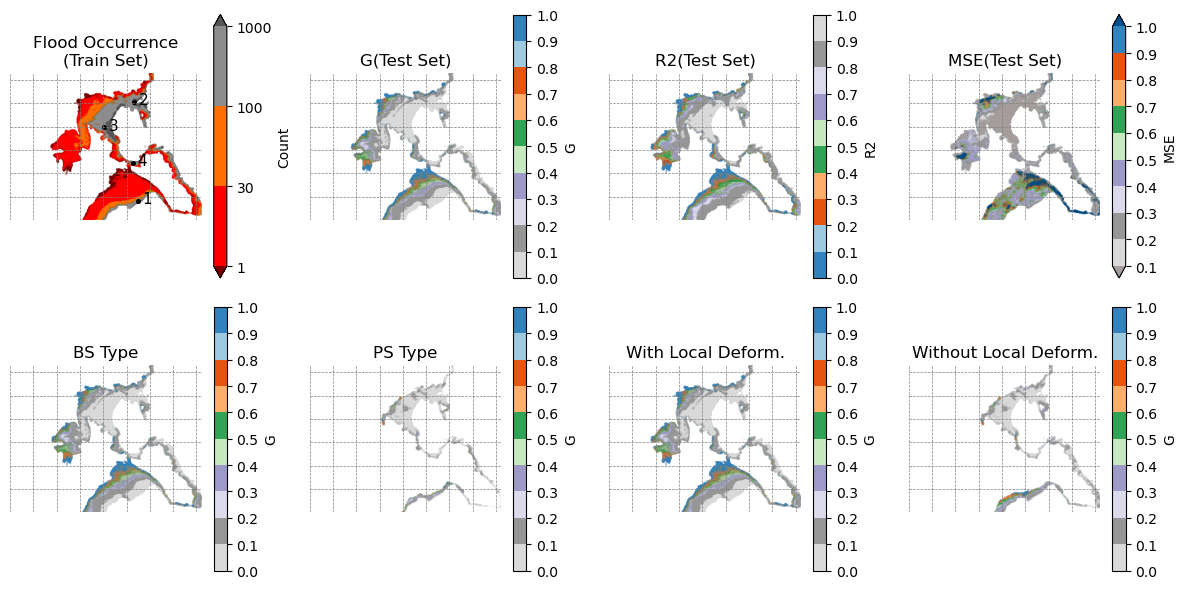

In [6]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
import pandas as pd
import numpy as np
import matplotlib.colors as mplcolors
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from sklearn.metrics import r2_score
import xarray as xr


#select particular representative gauge
reg = 'SR'
list_size = ['228', '550', '961', '1773', '3669', '6941']
columnname = str(54)
mask_size = list_size[2]
train_size = list_size[3]
idx= np.load(f'/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/data/processed/lat_lon_idx_{reg}_{mask_size}.npy')
idx_val = pd.read_csv(f'/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/model/{reg}/multifoldMC/PTHA/_Grid_scores_{train_size}.txt', sep=",")

#add columns to to the idx array
nflood_grids = len(idx)

# Using enumerate to add index to the list of coordinates
control_points = [[37.01,15.29],
            [37.06757,15.28709],
            [37.05266,15.26536],
            [37.03211,15.28632]]

#keep every second element from the list
# control_points = control_points[::2]
coordinates_list = pd.DataFrame(control_points,columns=['lat','lon'])
coordinates_list['id'] = coordinates_list.index+1
CP_list = [29720, 202349, 153030, 94497]
coordinates_list['idx'] = CP_list
coordinates_list['m'] = idx[CP_list, 1]
coordinates_list['n'] = idx[CP_list, 0]

fig, axs = plt.subplots(2, 4, figsize=(12,6))
axs = axs.ravel()

# Plot flood occurence
# Define the boundaries where the color changes
boundaries = [1, 30, 100, 1000]
custom_colors = ["#FF0000","#ff6f00","#8D8D8D"]  # 4 bins = 4 colors
cmap = mplcolors.ListedColormap(custom_colors)
cmap.set_over("#555555")   # Color for values > 1000
cmap.set_under("#790000")  # Color for values < 1
norm = mplcolors.BoundaryNorm(boundaries, len(custom_colors))

# Scatter plot
fr = axs[0].scatter(idx[:, 1], idx[:, 0], 
                    c=idx_val['count_train'] * 0.75, 
                    s=0.00025, 
                    cmap=cmap, 
                    norm=norm)

# Add colorbar with boundaries
cb = fig.colorbar(fr, ax=axs[0], boundaries=boundaries, extend='both')
cb.set_label('Count')
cb.set_ticks(boundaries)
cb.set_ticklabels(['1', '30', '100', '1000'])
axs[0].set_title('Flood Occurrence\n(Train Set)')


# Plot control points
axs[0].scatter(coordinates_list['m'], coordinates_list['n'], marker='o', s=7, c='black',alpha=1)
for i, txt in enumerate(coordinates_list['id']):
    if i == 4:
        axs[0].annotate(str(txt), (coordinates_list['m'][i] - 80, coordinates_list['n'][i] - 15) , fontsize=11, color='black')
    else:
        axs[0].annotate(str(txt), (coordinates_list['m'][i] + 30, coordinates_list['n'][i] - 15) , fontsize=11, color='black')

# Plot goodness of fit
cmap = plt.get_cmap('tab20c_r', 10)
g = axs[1].scatter(idx[:, 1], idx[:, 0], c=idx_val['Gfit'], s=0.00025, cmap=cmap, vmin=0, vmax=1)
cbar = fig.colorbar(g, ax=axs[1], label='G', ticks=np.linspace(0, 1, 11))
axs[1].set_title('G(Test Set)')

# Plot r2 
cmap = plt.get_cmap('tab20c', 10)
r2 = axs[2].scatter(idx[:, 1], idx[:, 0], c=idx_val['r2'], s=0.00025, cmap=cmap, vmin=0, vmax=1)
cb = fig.colorbar(r2, ax=axs[2], label='R2',ticks=np.linspace(0,1,11))
axs[2].set_title('R2(Test Set)')

# Plot mse all test that inundate
boundaries = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]
cmap = plt.get_cmap('tab20c_r', 10)
cmap.set_over("#004E8D")   # Color for values > 1000
cmap.set_under("#A59C9C")  # Color for values < 1
norm = mplcolors.BoundaryNorm(boundaries, 10)
idx_val['mse']= idx_val['mse']*np.full_like(idx_val['count_test'],(53500-int(train_size))/10000)/idx_val['count_test']
mse = axs[3].scatter(idx[:, 1], idx[:, 0], c=idx_val['mse'], s=0.00025, cmap=cmap, norm=norm)
cb = fig.colorbar(mse, ax=axs[3], label='MSE',extend='both')
cb.ax.yaxis.set_tick_params(which='minor',length=0) 
axs[3].set_title('MSE(Test Set)')

# Plot performance variable values
cmap = plt.get_cmap('tab20c_r', 10)
perf_var = 'Gfit'  # Gfit
count_threshold = 1

# Set NaN for rows where count_test is less than 1
idx_val[perf_var + '_BS'] = np.where(idx_val['count_test_BS'] < count_threshold, np.nan, idx_val[perf_var + '_BS'])
idx_val[perf_var + '_PS'] = np.where(idx_val['count_test_PS'] < count_threshold, np.nan, idx_val[perf_var + '_PS'])
idx_val[perf_var + '_def'] = np.where(idx_val['count_test_def'] < count_threshold, np.nan, idx_val[perf_var + '_def'])
idx_val[perf_var + '_nodef'] = np.where(idx_val['count_test_nodef'] < count_threshold, np.nan, idx_val[perf_var + '_nodef'])

# BS
bs = axs[4].scatter(idx[:, 1], idx[:, 0], c=idx_val[perf_var + '_BS'], s=0.00025, cmap=cmap, vmin=0, vmax=1)
cbar = fig.colorbar(bs, ax=axs[4],label='G',ticks=np.linspace(0,1,11))
axs[4].set_title('BS Type')

# PS
ps = axs[5].scatter(idx[:, 1], idx[:, 0], c=idx_val[perf_var + '_PS'], s=0.00025, cmap=cmap, vmin=0, vmax=1)
fig.colorbar(ps, ax=axs[5],label='G',ticks=np.linspace(0,1,11))
axs[5].set_title('PS Type')

# Deformation
deform = axs[6].scatter(idx[:, 1], idx[:, 0], c=idx_val[perf_var + '_def'], s=0.00025, cmap=cmap, vmin=0, vmax=1)
fig.colorbar(deform, ax=axs[6],label='G',ticks=np.linspace(0,1,11))
axs[6].set_title('With Local Deform.',)

# No Deformation
nondeform = axs[7].scatter(idx[:, 1], idx[:, 0], c=idx_val[perf_var + '_nodef'], s=0.00025, cmap=cmap, vmin=0, vmax=1)
fig.colorbar(deform, ax=axs[7],label='G',ticks=np.linspace(0,1,11))
axs[7].set_title('Without Local Deform.')

# Set axis scale as equal and add gridlines
for ax in axs:
    #keep gridlines but turn off axis borders and ticks
    ax.set_aspect('equal')
    ax.set_axis_off()
    ax.set_xlim([0, max(idx[:, 1])])
    ax.set_ylim([0, max(idx[:, 0])])
    ax.hlines(y=np.arange(0, max(idx[:, 0]), 150), xmin=0, xmax=max(idx[:, 1]), color='grey', linestyle='--', linewidth=0.5)
    ax.vlines(x=np.arange(0, max(idx[:, 1]), 150), ymin=0, ymax=max(idx[:, 0]), color='grey', linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.savefig(f'./grid_scores_{train_size}_{reg}.png',dpi=300, bbox_inches='tight', pad_inches=0.1)

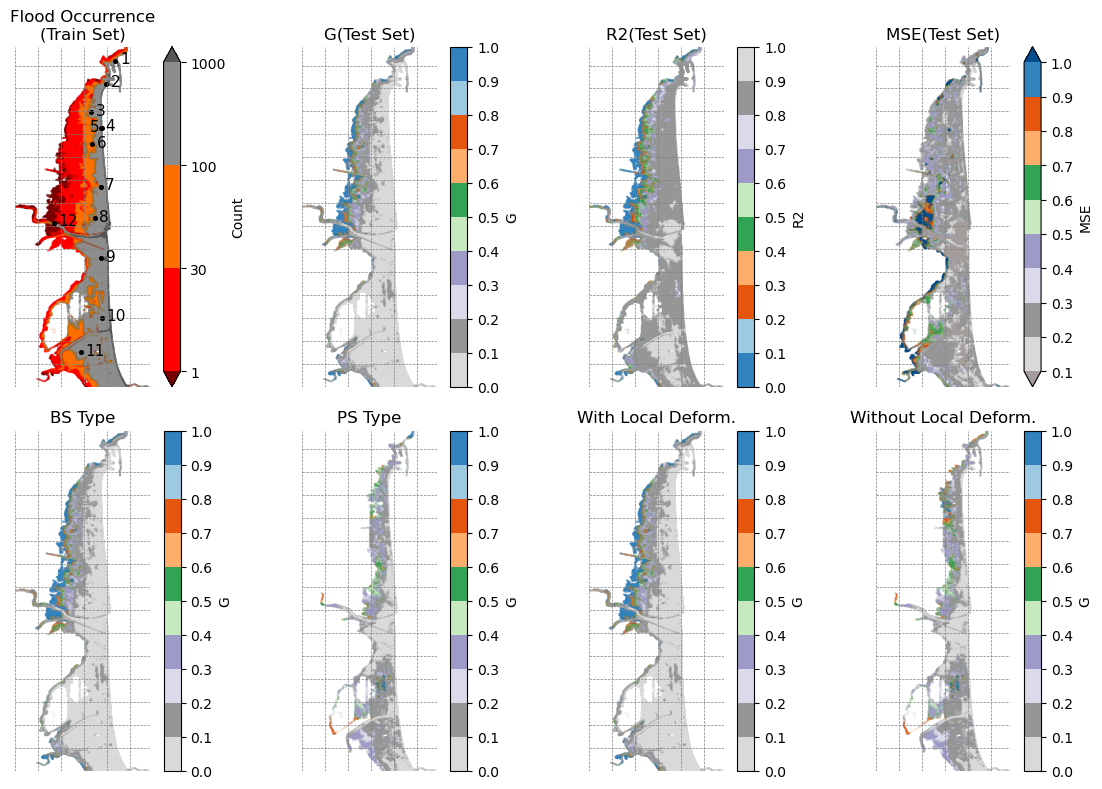

In [10]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
import pandas as pd
import numpy as np
import matplotlib.colors as mplcolors
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from sklearn.metrics import r2_score
import xarray as xr


#select particular representative gauge
reg = 'CT'
list_size = ['225', '529', '892', '1658', '3454', '7071'] 
columnname = str(38)
mask_size = '892'
train_size = list_size[3]
idx= np.load(f'/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/data/processed/lat_lon_idx_{reg}_{mask_size}.npy')
idx_val = pd.read_csv(f'/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/model/{reg}/multifoldMC/PTHA/_Grid_scores_{train_size}.txt', sep=",")

#add columns to to the idx array
nflood_grids = len(idx)

# Using enumerate to add index to the list of coordinates
control_points =  [[37.5022,15.0960],
            [37.48876,15.08936],
            [37.47193,15.07816],
            [37.46273,15.08527],
            [37.46252,15.08587],
            [37.45312,15.07874],
            [37.42821,15.08506],
            [37.40958,15.08075],
            [37.38595,15.08539],
            [37.35084,15.08575],
            [37.33049,15.07029],
            [37.40675,15.05037]]

#keep every second element from the list
# control_points = control_points[::2]
coordinates_list = pd.DataFrame(control_points,columns=['lat','lon'])
coordinates_list['id'] = coordinates_list.index+1
CP_list = [573785, 561728, 530792, 507751, 507274, 481772, 400027, 318807, 229769, 155881, 82539, 303797]
coordinates_list['idx'] = CP_list
coordinates_list['m'] = idx[CP_list, 1]
coordinates_list['n'] = idx[CP_list, 0]

fig, axs = plt.subplots(2, 4, figsize=(12,8))
axs = axs.ravel()

# Plot flood occurence
# Define the boundaries where the color changes
boundaries = [1, 30, 100, 1000]
custom_colors = ["#FF0000","#ff6f00","#8D8D8D"]  # 4 bins = 4 colors
cmap = mplcolors.ListedColormap(custom_colors)
cmap.set_over("#555555")   # Color for values > 1000
cmap.set_under("#790000")  # Color for values < 1
norm = mplcolors.BoundaryNorm(boundaries, len(custom_colors))

# Scatter plot
fr = axs[0].scatter(idx[:, 1], idx[:, 0], 
                    c=idx_val['count_train'] * 0.75, 
                    s=0.00025, 
                    cmap=cmap, 
                    norm=norm)

# Add colorbar with boundaries
cb = fig.colorbar(fr, ax=axs[0], boundaries=boundaries, extend='both')
cb.set_label('Count')
cb.set_ticks(boundaries)
cb.set_ticklabels(['1', '30', '100', '1000'])
cb.ax.yaxis.set_tick_params(which='minor', length=0)
axs[0].set_title('Flood Occurrence\n(Train Set)')


# Plot control points
axs[0].scatter(coordinates_list['m'], coordinates_list['n'], marker='o', s=7, c='black',alpha=1)
for i, txt in enumerate(coordinates_list['id']):
    if i == 4:
        axs[0].annotate(str(txt), (coordinates_list['m'][i] - 80, coordinates_list['n'][i] - 15) , fontsize=11, color='black')
    else:
        axs[0].annotate(str(txt), (coordinates_list['m'][i] + 30, coordinates_list['n'][i] - 15) , fontsize=11, color='black')

# Plot goodness of fit

cmap = plt.get_cmap('tab20c_r', 10)
perf_var = 'Gfit'  # Gfit
g = axs[1].scatter(idx[:, 1], idx[:, 0], c=idx_val[perf_var], s=0.00025, cmap=cmap, vmin=0, vmax=1)
cbar = fig.colorbar(g, ax=axs[1], label='G', ticks=np.linspace(0, 1, 11))
axs[1].set_title('G(Test Set)')

# Plot r2 
cmap = plt.get_cmap('tab20c', 10)
perf_var = 'R2'  # Gfit
r2 = axs[2].scatter(idx[:, 1], idx[:, 0], c=idx_val['r2'], s=0.00025, cmap=cmap, vmin=0, vmax=1)
cb = fig.colorbar(r2, ax=axs[2], label='R2',ticks=np.linspace(0,1,11))
axs[2].set_title('R2(Test Set)')

# Plot mse all test that inundate
boundaries = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]
cmap = plt.get_cmap('tab20c_r', 10)
cmap.set_over("#004E8D")   # Color for values > 1000
cmap.set_under("#A59C9C")  # Color for values < 1
norm = mplcolors.BoundaryNorm(boundaries, 10)
idx_val['mse']= idx_val['mse']*np.full_like(idx_val['count_test'],(53500-int(train_size))/10000)/idx_val['count_test']
mse = axs[3].scatter(idx[:, 1], idx[:, 0], c=idx_val['mse'], s=0.00025, cmap=cmap, norm=norm)
cb = fig.colorbar(mse, ax=axs[3], label='MSE',extend='both')
cb.ax.yaxis.set_tick_params(which='minor',length=0) 
axs[3].set_title('MSE(Test Set)')

# Plot performance variable values
cmap = plt.get_cmap('tab20c_r', 10)
perf_var = 'Gfit'  # Gfit
count_threshold = 1

# Set NaN for rows where count_test is less than 1
idx_val[perf_var + '_BS'] = np.where(idx_val['count_test_BS'] < count_threshold, np.nan, idx_val[perf_var + '_BS'])
idx_val[perf_var + '_PS'] = np.where(idx_val['count_test_PS'] < count_threshold, np.nan, idx_val[perf_var + '_PS'])
idx_val[perf_var + '_def'] = np.where(idx_val['count_test_def'] < count_threshold, np.nan, idx_val[perf_var + '_def'])
idx_val[perf_var + '_nodef'] = np.where(idx_val['count_test_nodef'] < count_threshold, np.nan, idx_val[perf_var + '_nodef'])

# BS
bs = axs[4].scatter(idx[:, 1], idx[:, 0], c=idx_val[perf_var + '_BS'], s=0.00025, cmap=cmap, vmin=0, vmax=1)
cbar = fig.colorbar(bs, ax=axs[4],label='G',ticks=np.linspace(0,1,11))
axs[4].set_title('BS Type')

# PS
ps = axs[5].scatter(idx[:, 1], idx[:, 0], c=idx_val[perf_var + '_PS'], s=0.00025, cmap=cmap, vmin=0, vmax=1)
fig.colorbar(ps, ax=axs[5],label='G',ticks=np.linspace(0,1,11))
axs[5].set_title('PS Type')

# Deformation
deform = axs[6].scatter(idx[:, 1], idx[:, 0], c=idx_val[perf_var + '_def'], s=0.00025, cmap=cmap, vmin=0, vmax=1)
fig.colorbar(deform, ax=axs[6],label='G',ticks=np.linspace(0,1,11))
axs[6].set_title('With Local Deform.',)

# No Deformation
nondeform = axs[7].scatter(idx[:, 1], idx[:, 0], c=idx_val[perf_var + '_nodef'], s=0.00025, cmap=cmap, vmin=0, vmax=1)
fig.colorbar(deform, ax=axs[7],label='G',ticks=np.linspace(0,1,11))
axs[7].set_title('Without Local Deform.')

# Set axis scale as equal and add gridlines
for ax in axs:
    #keep gridlines but turn off axis borders and ticks
    ax.set_aspect('equal')
    ax.set_axis_off()
    ax.set_xlim([0, max(idx[:, 1])])
    ax.set_ylim([0, max(idx[:, 0])])
    ax.hlines(y=np.arange(0, max(idx[:, 0]), 150), xmin=0, xmax=max(idx[:, 1]), color='grey', linestyle='--', linewidth=0.5)
    ax.vlines(x=np.arange(0, max(idx[:, 1]), 150), ymin=0, ymax=max(idx[:, 0]), color='grey', linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.savefig(f'./grid_scores_{train_size}_{reg}.png',dpi=300, bbox_inches='tight', pad_inches=0.1)

Paper2

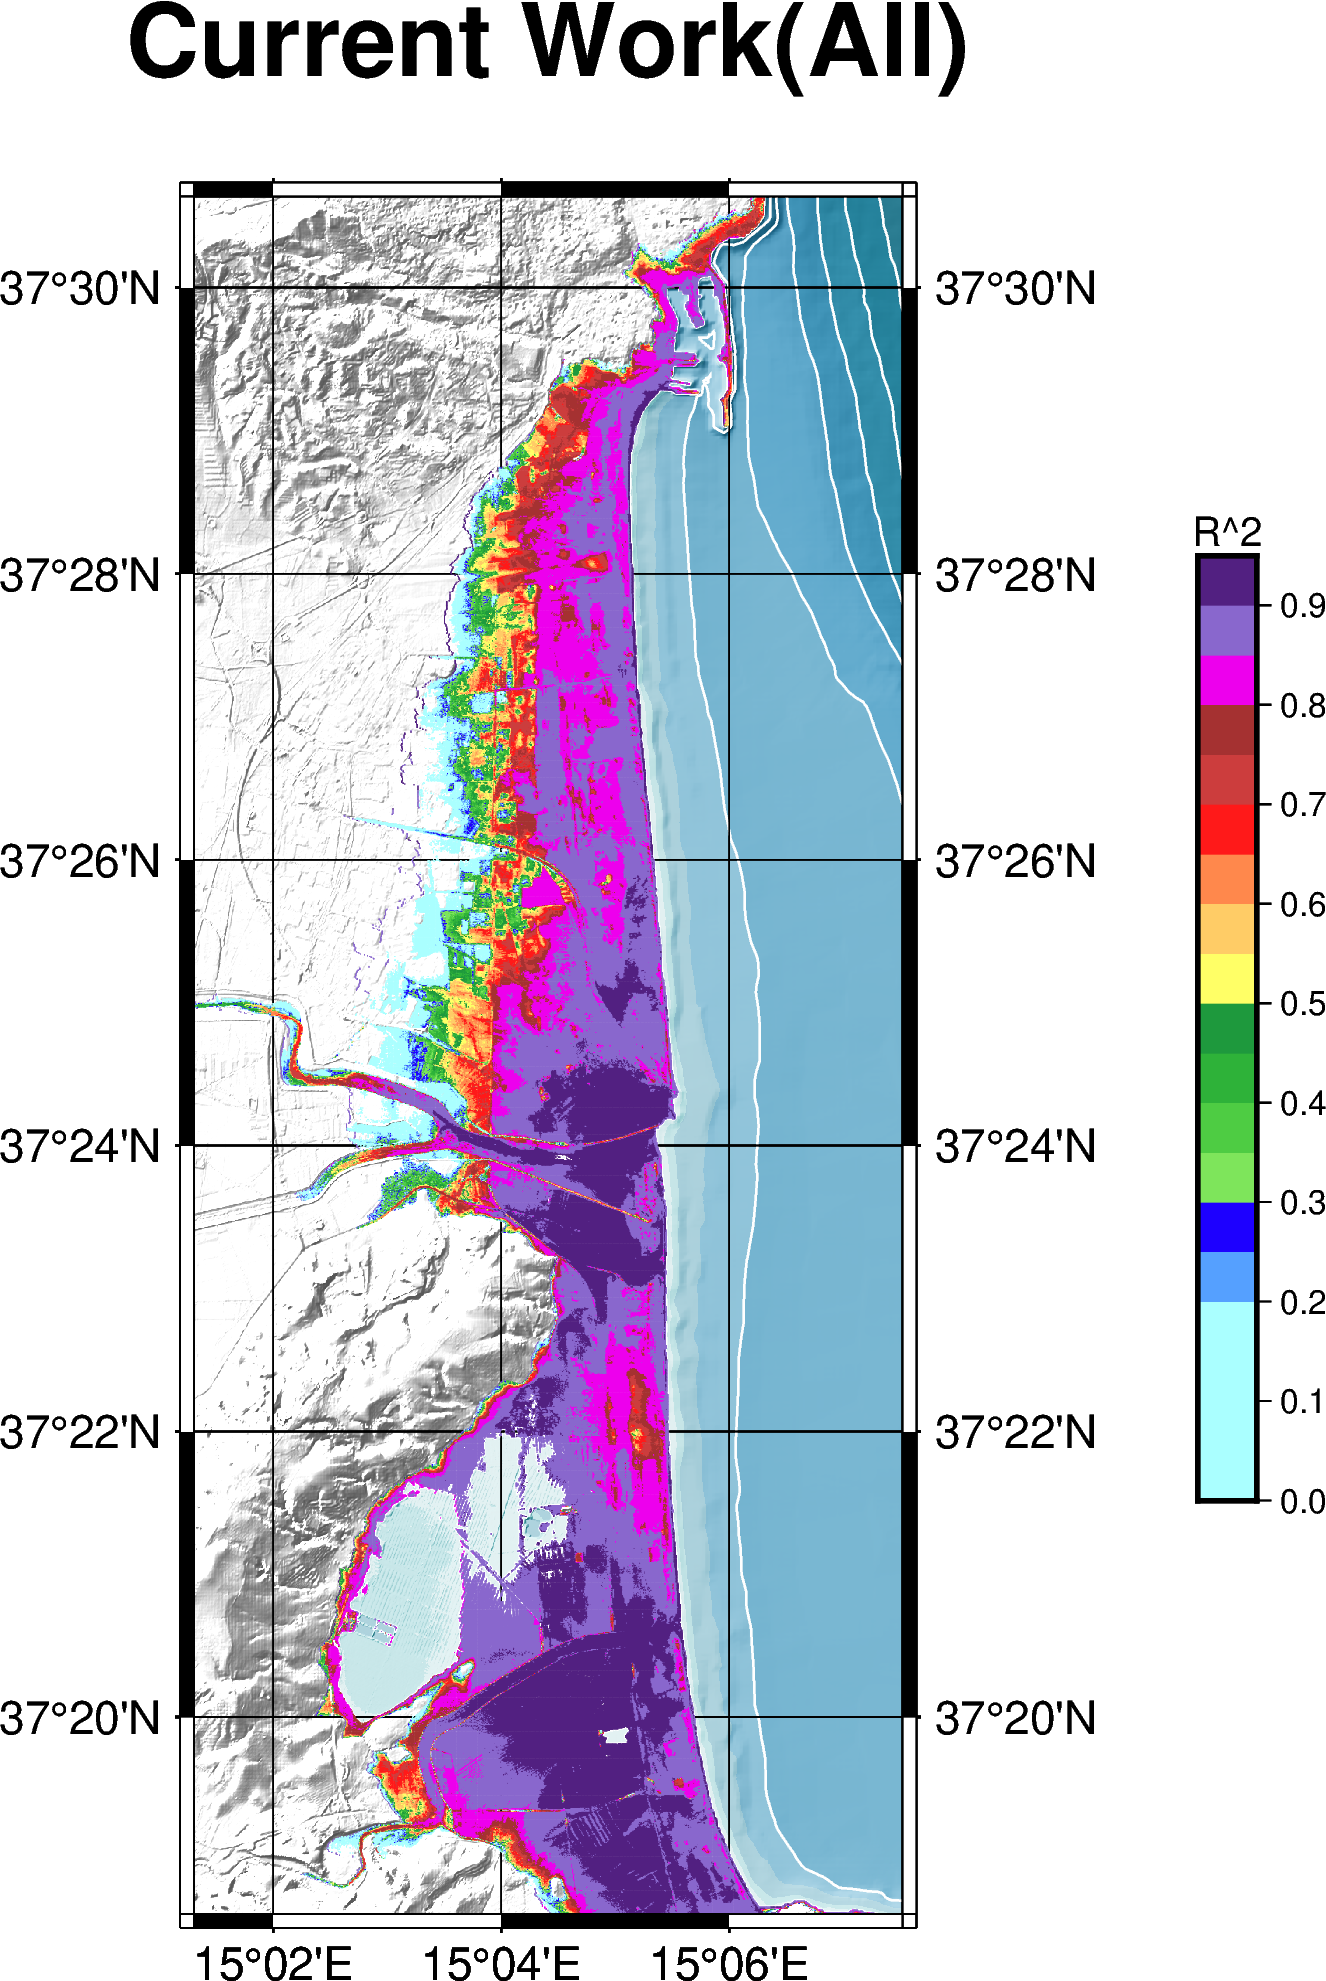

In [1]:
import pandas as pd
import numpy as np
import xarray as xr
import pygmt

# Using enumerate to add index to the list of coordinates
control_points =  [[37.5022,15.0960],
            [37.48876,15.08936],
            [37.47193,15.07816],
            [37.46273,15.08527],
            [37.46252,15.08587],
            [37.45312,15.07874],
            [37.42821,15.08506],
            [37.40958,15.08075],
            [37.38595,15.08539],
            [37.35084,15.08575],
            [37.33049,15.07029],
            [37.40675,15.05037]]


#select particular representative gauge
reg = 'CT'
list_size =  ['225', '529','892','1658','3454','7071']    
columnname = str(38)
mask_size = '892'
train_size = list_size[3]

# Load the elevation from netcdf grid
grid_CT = xr.open_dataset('../../../data/processed/CT_defbathy.nc',engine='netcdf4')
#get lat long limits from the grid
ymin = grid_CT['y'].min().values
ymax = grid_CT['y'].max().values
xmin = grid_CT['x'].min().values
xmax = grid_CT['x'].max().values

grid_CT_P1 = xr.open_dataset('./extra/r_squared_test.nc',engine='netcdf4')

#add y and x coordinates from grid_CT to grid_CT_P1
grid_CT_P1['y'] = grid_CT['y']
grid_CT_P1['x'] = grid_CT['x']

grid_CT_P1 = xr.open_dataset('./extra/r2_topo_test.nc',engine='netcdf4')
temp = grid_CT_P1['r2topo']
temp = temp.where(temp>0,0)
grid_CT_P1['r2topo'] = temp

# Plot grid
fig = pygmt.Figure()

with fig.subplot(
        nrows=1,
        ncols=4,
        subsize = ["8c","20c"],
        sharey = True,
        frame = ["ag"],
        ):
    # with fig.set_panel(panel=[0,0]):
    #     cptfile = './extra/bathy2.cpt'
    #     cmap = pygmt.makecpt(cmap=cptfile,continuous=False)
    #     fig.grdimage(grid_CT['z'], cmap=True, shading=True,region=[xmin,xmax,ymin,ymax],projection='M6c',frame = ["+tFlood occurence"])
    #     fig.grdcontour(grid_CT['z'], levels=10, pen='0.5p,white', limit=[-100, 0],projection='M6c')
    #     cptfile = './extra/occurence.cpt'
    #     cmap = pygmt.makecpt(cmap=cptfile,continuous=False)


    #     idx_val = pd.read_csv(f'/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/model/{reg}/multifoldMC/PTHA/_Grid_scores_{train_size}.txt', sep=",")
    #     idx_val = idx_val[~idx_val['count_train'].isna()]
    #     # Define bins and labels
    #     bins = [0, 10, 30, 100, 1000, np.inf]   # 5 intervals
    #     labels = [f"{int(bins[i])}-{int(bins[i+1])}" if not np.isinf(bins[i+1]) else f"{int(bins[i])}+" for i in range(len(bins)-1)]
        
    #     # Convert categories to numeric codes for coloring
    #     idx_val['count_train'] = pd.cut(idx_val['count_train'], bins=bins, labels=labels, include_lowest=True)
    #     idx_val['count_train'] = idx_val['count_train'].astype('category')
    #     cb_annots = list(idx_val.count_train.cat.categories)

    #     # Create a CPT for numeric codes from 0 to N-1
    #     n_bins = len(labels)
    #     cpt = pygmt.makecpt(cmap="inferno", series=[idx_val.count_train.cat.codes.min(), idx_val.count_train.cat.codes.max(), 1], color_model="+c" + ",".join(cb_annots))
                            
    #     fig.plot(
    #         x=idx_val['lon'],
    #         y=idx_val['lat'],
    #         fill=idx_val.count_train.cat.codes.astype(int),
    #         style='s0.01c',
    #         cmap=True,
    #         projection='M6c',
    #         frame=["ag"]
    #     )

    #     # Create colorbar with custom annotations from your string labels
    #     fig.colorbar(
    #         cmap=cpt,
    #         frame=["xafg", f"y+lCount", f"xa{','.join(labels)}"],
    #         position="JML+o2.5c/-2.5c+w8c/0.5c"
    #     )

    #     # Plot control points
    #     coordinates_list = pd.DataFrame(control_points,columns=['lat','lon'])
    #     coordinates_list['id'] = coordinates_list.index+1
        
    #     fig.plot(x=coordinates_list.lon, 
    #              y=coordinates_list.lat, 
    #              style="c0.15c", fill="white", pen="black",
    #              projection='M6c', frame=["ag"])

    #     #plot control POIs and annotate
    #     for i in range(len(control_points)):
    #         if i == 3:
    #             fig.text(x=control_points[i][1],y=control_points[i][0],text=f'{i+1}',offset='0.25c',font='12p,Helvetica-Bold,black',justify='BR',projection='M6c')
    #         elif i == 4:
    #             fig.text(x=control_points[i][1],y=control_points[i][0],text=f'{i+1}',offset='0.25c',font='12p,Helvetica-Bold,black',justify='TL',projection='M6c')
    #         elif i == 11:
    #             fig.text(x=control_points[i][1],y=control_points[i][0],text=f'{i+1}',offset='0.25c',font='12p,Helvetica-Bold,white',justify='TL',projection='M6c')
    #         else:
    #             fig.text(x=control_points[i][1],y=control_points[i][0],text=f'{i+1}',offset='0.25c',font='12p,Helvetica-Bold,black',justify='TR',projection='M6c')

    #     # fig.plot(x=idx_val['lon'], y=idx_val['lat'],fill=idx_val['count_train'],style='s0.01c',cmap = True,projection='M6c',frame = ["ag"])
    #     # fig.colorbar(frame=["x+lFlood occurence"], position="JML+o0.5c/-2.5c+w8c/0.5c") 
    # with fig.set_panel(panel=[0,1]):
    #     cptfile = './extra/bathy2.cpt'
    #     cmap = pygmt.makecpt(cmap=cptfile,continuous=False)
    #     fig.grdimage(grid_CT['z'], cmap=True, shading=True,region=[xmin,xmax,ymin,ymax],projection='M6c',frame = ["+tStorrøsten(2024)"])
    #     fig.grdcontour(grid_CT['z'], levels=10, pen='0.5p,white', limit=[-100, 0],projection='M6c')
    #     cptfile = './extra/special.cpt'
    #     cmap = pygmt.makecpt(cmap=cptfile, continuous=False)
    #     # fig.grdimage(grid_CT_P1['r-squared'],cmap = True,projection='M6c',frame = ["ag"],nan_transparent=True) #,nan_transparent='+z0'
    #     fig.grdimage(grid_CT_P1['r2topo'],cmap = True,projection='M6c',frame = ["ag"],nan_transparent='+z0')

    # with fig.set_panel(panel=[0,2]):
    #     cptfile = './extra/bathy2.cpt'
    #     cmap = pygmt.makecpt(cmap=cptfile,continuous=False)
    #     fig.grdimage(grid_CT['z'], cmap=True, shading=True,region=[xmin,xmax,ymin,ymax],projection='M6c',frame = ["+tCurrent Work(PS)"])
    #     fig.grdcontour(grid_CT['z'], levels=10, pen='0.5p,white', limit=[-100, 0],projection='M6c')
    #     cptfile = './extra/special.cpt'
    #     cmap = pygmt.makecpt(cmap=cptfile, continuous=False)
    #     idx_val = pd.read_csv(f'/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/model/{reg}/multifoldMC/PTHA/_Grid_scores_{train_size}_PSHalf.txt', sep=",")
    #     idx_val = idx_val[~(idx_val['r2_PS'] >= 1)]
    #     idx_val = idx_val[~(idx_val['r2_PS'] <= 0)]
    #     idx_val = idx_val[~idx_val['r2_PS'].isna()]
    #     fig.plot(x=idx_val['lon'], y=idx_val['lat'],fill=idx_val['r2_PS'],style='s0.01c',cmap = True,projection='M6c',frame = ["ag"])

    with fig.set_panel(panel=[0,3]):
        cptfile = './extra/bathy2.cpt'
        cmap = pygmt.makecpt(cmap=cptfile,continuous=False)
        fig.grdimage(grid_CT['z'], cmap=True, shading=True,region=[xmin,xmax,ymin,ymax],projection='M6c',frame = ["+tCurrent Work(All)"])
        fig.grdcontour(grid_CT['z'], levels=10, pen='0.5p,white', limit=[-100, 0],projection='M6c')
        cptfile = './extra/special.cpt'
        cmap = pygmt.makecpt(cmap=cptfile, continuous=False)
        idx_val = pd.read_csv(f'/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/model/{reg}/multifoldMC/PTHA/_Grid_scores_{train_size}.txt', sep=",")
        idx_val = idx_val[~(idx_val['r2'] >= 1)]
        idx_val = idx_val[~(idx_val['r2'] <= 0)]
        idx_val = idx_val[~idx_val['r2'].isna()]
        fig.plot(x=idx_val['lon'], y=idx_val['lat'],fill=idx_val['r2'],style='s0.01c',cmap = True,projection='M6c',frame = ["ag"])
        fig.colorbar(frame=["xa0.1f0.1","y+lR^2"], position="JMR+o0.5c/-2.5c+w8c/0.5c") 

#save
savefile = f'./grid_scores_{train_size}_{reg}_P2.png'
fig.savefig(savefile,dpi=300)
fig.show()